# WFS Loudspeaker Array — Design Notes and Sanity Checks

**MSc thesis** - Auditory Distance Perception in Wave Field Synthesis: Pre-Attentive Neural Processing in a Cocktail-Party Environment

This notebook is a companion artefact to the thesis. Its purpose is to:

1. Illustrate the acoustic and experimental design choices (array geometry, spatial aliasing,
   WFS driving function, masker calibration, oddball sequence structure, trigger-timing correction).
2. Justify several implementation decisions with first-principles derivations and sanity checks.
3. Validate the acoustic measurement procedure (logarithmic sweep / RT60 method) used to
   characterise the listening room.

Requirements: this notebook calls `sfs.array.linear`, `sfs.array.concatenate`,
`sfs.td.wfs.point_25d`, and `sfs.tapering.tukey` — the same functions used in
`wfs_pipeline_scene_generator.py` — so the array geometry and driving-function results below
are computed with the real WFS library, not a reimplementation. Run `pip install sfs` first.

## Table of contents

1. [Experimental parameters](#sec1)
2. [WFS loudspeaker-array geometry](#sec2)
3. [WFS 2.5D driving-function theory (from first principles)](#sec3)
4. [Single-source validation — target at near vs. far distance](#sec4)
5. [Spatial maskers — layout and level calibration](#sec5)
6. [Trigger-timing correction (acoustic flight time)](#sec6)
7. [Oddball sequence structure (Blocks A / B / C)](#sec7)
8. [Acoustic validation — logarithmic sine sweep (RT60 measurement)](#sec_sweep)
9. [Summary — which figure goes where in the thesis](#sec9)

Run the cell below once to install the `sfs` package if it isn't already available in this environment.


In [1]:
!pip install sfs


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import sfs
from sfs.array import linear as build_linear_wall, concatenate as concat_arrays

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Wong (2011) colour-blind-safe palette, used throughout for consistent figures.
COLORS = {
    "std_A":  "#0072B2",
    "dev_A":  "#D55E00",
    "std_B":  "#009E73",
    "dev_B":  "#CC79A7",
    "ctrl_C": "#E69F00",
    "mmn":    "#D55E00",
    "p3a":    "#009E73",
    "ssa":    "#CC79A7",
    "active": "#F0E442",
    "inactive": "#BBBBBB",
}

C_SOUND = 343.0  # m/s, speed of sound
print("Setup complete.")

Setup complete.


<a id="sec1"></a>
## 1. Experimental parameters

The constants below match the actual parameters of the experiment, so that every figure in
this notebook is generated with the *real* design values rather than illustrative placeholders.

In [3]:
CONFIG = {
    # --- array geometry ---
    "N_PER_WALL": 15,
    "SPACING": 0.176,        # m, centre-to-centre loudspeaker spacing
    "WALL_DIST": 1.5,        # m, distance from listening centre to each wall

    # --- audio / calibration ---
    "FS": 48000,
    "TARGET_SPL": 66,        # dB SPL
    "MASKER_SPL": 70,        # dB SPL (combined, 4 maskers)

    # --- spatial design ---
    "TARGET_AZIMUTH": 0,
    "DISTANCE_NEAR": 2.0,
    "DISTANCE_FAR": 5.0,
    "DISTANCE_INTERMEDIATE": [2.8, 4.0],
    "MASKER_AZIMUTHS": [60, -60, 120, -120],
    "MASKER_DISTANCE": 3.0,

    # --- timing ---
    "SOA": 0.900,
    "TARGET_DURATION": 0.600,
}

TRIGGER_CODES = {
    'A_standard': 11, 'A_deviant': 12,
    'B_standard': 21, 'B_deviant': 22,
    'C_control': 31,
    'block_start': 99,
}

BLOCKS = {
    'A': {'name': 'Far_standard_Near_deviant',
          'standard_distance': CONFIG["DISTANCE_FAR"], 'deviant_distance': CONFIG["DISTANCE_NEAR"],
          'n_standards': 400, 'n_deviants': 100, 'lead_in': 15,
          'trigger_standard': TRIGGER_CODES['A_standard'], 'trigger_deviant': TRIGGER_CODES['A_deviant']},
    'B': {'name': 'Near_standard_Far_deviant',
          'standard_distance': CONFIG["DISTANCE_NEAR"], 'deviant_distance': CONFIG["DISTANCE_FAR"],
          'n_standards': 400, 'n_deviants': 100, 'lead_in': 15,
          'trigger_standard': TRIGGER_CODES['B_standard'], 'trigger_deviant': TRIGGER_CODES['B_deviant']},
    'C': {'name': 'Many_standards_control',
          'distances': [CONFIG["DISTANCE_NEAR"], 2.8, 4.0, CONFIG["DISTANCE_FAR"], 3.4],
          'n_per_distance': 100, 'lead_in': 15,
          'trigger_control': TRIGGER_CODES['C_control']},
}

pd.DataFrame([
    {"Block": k, "Name": v["name"],
     "n_trials": v.get("n_standards", 0) + v.get("n_deviants", 0) + v.get("lead_in", 0)
                 if k in "AB" else v["n_per_distance"] * len(v["distances"]) + v["lead_in"]}
    for k, v in BLOCKS.items()
])

,Block,Name,n_trials
0,A,Far_standard_Near_deviant,515
1,B,Near_standard_Far_deviant,515
2,C,Many_standards_control,515


<a id="sec2"></a>
## 2. WFS loudspeaker-array geometry

The array is a **square of 4 linear sub-arrays** ("walls"), 15 loudspeakers each (60 total),
176 mm centre-to-centre spacing, each wall 1.5 m from the listening centre:

* channels **0–14**  → **front** wall (y = +1.5 m, inward normal `[0,-1,0]`)
* channels **15–29** → **right** wall (x = +1.5 m, inward normal `[-1,0,0]`)
* channels **30–44** → **back**  wall (y = -1.5 m, inward normal `[0,+1,0]`)
* channels **45–59** → **left**  wall (x = -1.5 m, inward normal `[+1,0,0]`)

In [4]:
# Array geometry built with the actual sfs.array helpers used in the rendering pipeline
# (build_square_array is copied verbatim from wfs_pipeline_scene_generator.py).

def build_square_array(n_per_wall, spacing, wall_dist):
    back  = build_linear_wall(n_per_wall, spacing, center=[0, -wall_dist, 0], orientation=[0, 1, 0])
    front = build_linear_wall(n_per_wall, spacing, center=[0,  wall_dist, 0], orientation=[0, -1, 0])
    right = build_linear_wall(n_per_wall, spacing, center=[ wall_dist, 0, 0], orientation=[-1, 0, 0])
    left  = build_linear_wall(n_per_wall, spacing, center=[-wall_dist, 0, 0], orientation=[ 1, 0, 0])
    return concat_arrays(left, front, right, back)


ARRAY = build_square_array(CONFIG["N_PER_WALL"], CONFIG["SPACING"], CONFIG["WALL_DIST"])
ARRAY_X = ARRAY.x
ARRAY_N = ARRAY.n
n_per_wall = CONFIG["N_PER_WALL"]

# NOTE (verify on your machine): sfs is not installed in this sandbox, so the assumption
# that sfs.array.concatenate(left, front, right, back) preserves argument order (i.e. that
# ARRAY.x rows 0:15 are 'left', 15:30 are 'front', etc.) is UNTESTED here. If the wall labels
# below don't match what you see when you inspect ARRAY_N (the loudspeaker normals) after
# running this cell for real, reorder this list to match the actual sfs.array.concatenate output.
ARRAY_WALL = (['left'] * n_per_wall + ['front'] * n_per_wall +
              ['right'] * n_per_wall + ['back'] * n_per_wall)
print(f"Array built: {len(ARRAY_X)} loudspeakers ({CONFIG['N_PER_WALL']} per wall x 4 walls)")
print("Wall-label assumption not verified against a real sfs install -- check ARRAY_N ordering.")


def azimuth_to_cartesian(azimuth_deg, distance):
    # 0 deg = front (+Y), +90 deg = right (+X), -90 deg = left (-X), 180 deg = back (-Y).
    az = np.radians(azimuth_deg)
    return np.array([distance * np.sin(az), distance * np.cos(az), 0.0])


Array built: 60 loudspeakers (15 per wall x 4 walls)
Wall-label assumption not verified against a real sfs install -- check ARRAY_N ordering.


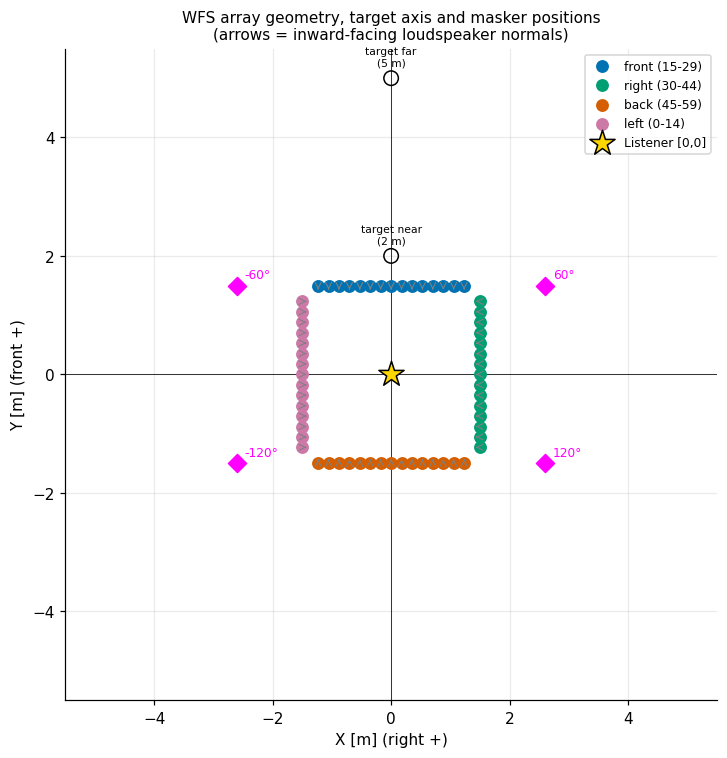

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
wall_colors = {'front': '#0072B2', 'right': '#009E73', 'back': '#D55E00', 'left': '#CC79A7'}

for wall in ['front', 'right', 'back', 'left']:
    idx = [i for i, w in enumerate(ARRAY_WALL) if w == wall]
    ax.scatter(ARRAY_X[idx, 0], ARRAY_X[idx, 1], c=wall_colors[wall], s=55,
               label=f"{wall} ({idx[0]}-{idx[-1]})", zorder=3)

for i in range(len(ARRAY_X)):
    ax.annotate('', xy=(ARRAY_X[i, 0] + 0.12 * ARRAY_N[i, 0], ARRAY_X[i, 1] + 0.12 * ARRAY_N[i, 1]),
                xytext=(ARRAY_X[i, 0], ARRAY_X[i, 1]),
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.7))

ax.scatter(0, 0, marker='*', s=300, c='gold', edgecolors='k', zorder=5, label='Listener [0,0]')

# target axis (azimuth 0, near & far)
for d, tag in [(CONFIG["DISTANCE_NEAR"], 'near'), (CONFIG["DISTANCE_FAR"], 'far')]:
    p = azimuth_to_cartesian(0, d)
    ax.scatter(*p[:2], marker='o', s=90, facecolors='none', edgecolors='k', zorder=4)
    ax.annotate(f"target {tag}\n({d:.0f} m)", p[:2], fontsize=7, ha='center',
                xytext=(0, 8), textcoords='offset points')

# masker positions
for az in CONFIG["MASKER_AZIMUTHS"]:
    p = azimuth_to_cartesian(az, CONFIG["MASKER_DISTANCE"])
    ax.scatter(*p[:2], marker='D', s=70, c='magenta', zorder=4)
    ax.annotate(f'{az}°', p[:2], fontsize=8, color='magenta',
                xytext=(5, 5), textcoords='offset points')

ax.set_xlim(-5.5, 5.5); ax.set_ylim(-5.5, 5.5)
ax.set_aspect('equal'); ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('X [m] (right +)'); ax.set_ylabel('Y [m] (front +)')
ax.set_title('WFS array geometry, target axis and masker positions\n'
              '(arrows = inward-facing loudspeaker normals)', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

**Why this matters for the design.** The spatial (Nyquist) sampling of the secondary-source
distribution sets an upper bound on the frequency range that can be synthesised without
spatial aliasing artefacts:

$$f_{alias} = \frac{c}{2\,\Delta x}$$

with $\Delta x$ the loudspeaker spacing. Below, this is evaluated for the actual spacing used
(176 mm) and compared against the spectral content of speech (CVC target words) and the
masker narratives, which is the relevant justification for why this spacing was considered
acceptable for the stimulus material used in this experiment.

In [7]:
f_alias = C_SOUND / (2 * CONFIG["SPACING"])
print(f"Loudspeaker spacing        : {CONFIG['SPACING']*1000:.0f} mm")
print(f"Spatial aliasing frequency : {f_alias:.0f} Hz")
print()
print("Context: speech intelligibility and most perceptually-relevant spatial cues for")
print("CVC target words and masker narratives are concentrated below ~4-5 kHz; energy")
print(f"above the {f_alias:.0f} Hz aliasing limit still reaches the listener, but its *spatial* ")
print("rendering becomes physically inexact above this frequency (secondary interference ")
print("side-lobes). This is a standard, accepted trade-off in WFS systems of this speaker ")
print("density and should be reported explicitly as a design limitation in the Methods section.")

Loudspeaker spacing        : 176 mm
Spatial aliasing frequency : 974 Hz

Context: speech intelligibility and most perceptually-relevant spatial cues for
CVC target words and masker narratives are concentrated below ~4-5 kHz; energy
above the 974 Hz aliasing limit still reaches the listener, but its *spatial* 
rendering becomes physically inexact above this frequency (secondary interference 
side-lobes). This is a standard, accepted trade-off in WFS systems of this speaker 
density and should be reported explicitly as a design limitation in the Methods section.


<a id="sec3"></a>
## 3. WFS 2.5D driving-function theory (from first principles)

Wave Field Synthesis reconstructs a desired sound field inside a listening area from a
continuous (here, discretised) distribution of secondary sources on its boundary, based on the
Kirchhoff–Helmholtz / Rayleigh integral. For a virtual **point source** at position $\mathbf{x}_s$,
the practical 2.5D driving function for a secondary source at $\mathbf{x}_0$ with inward normal
$\mathbf{n}_0$ is commonly written as:

$$
D(\mathbf{x}_0,\omega) \;=\; w(\mathbf{x}_0)\,\underbrace{\sqrt{\dfrac{|\mathbf{x}_{ref}-\mathbf{x}_0|}
{|\mathbf{x}_{ref}-\mathbf{x}_0|+|\mathbf{x}_s-\mathbf{x}_0|}}}_{\text{2.5D reference amplitude correction}}
\;\cdot\;\underbrace{\dfrac{(\mathbf{x}_0-\mathbf{x}_s)\cdot\mathbf{n}_0}{|\mathbf{x}_0-\mathbf{x}_s|^{3/2}}}_{\text{obliquity} \times \text{1/}\sqrt{r}\text{ amplitude decay}}
\;\cdot\;e^{-j\omega|\mathbf{x}_0-\mathbf{x}_s|/c}
$$

with a **secondary-source selection (activity) window**

$$
w(\mathbf{x}_0)=\begin{cases}1 & (\mathbf{x}_0-\mathbf{x}_s)\cdot\mathbf{n}_0 > 0\\[2pt]0 & \text{otherwise}\end{cases}
$$

Intuitively: (1) each active loudspeaker fires with a **delay** equal to the source-to-speaker
propagation time $|\mathbf{x}_0-\mathbf{x}_s|/c$, (2) an **amplitude weight** combining the
obliquity factor (how directly the speaker "faces" the source) and spherical $1/\sqrt{r}$ decay,
and (3) only loudspeakers on the side of the array that the virtual source is "beyond" are
switched on — the criterion above is exactly the sign test used to decide this.

The theory above is exactly what `sfs.td.wfs.point_25d` implements internally. The cells below
call that function directly (not a reimplementation) to compute delay/weight/active per
loudspeaker, then visualise the resulting sound field to show *why* near vs. far virtual sources
should produce physically distinguishable wavefronts at the listening position — the acoustic
basis for the looming/receding MMN manipulation used in Blocks A/B.

In [8]:
LISTENER_POS = np.zeros(3)

def wfs_point25d_driving(array_x, array_n, xs, xref=LISTENER_POS):
    # Wraps the actual sfs.td.wfs.point_25d call used in render_point_source_wfs()
    # (wfs_pipeline_scene_generator.py), returning (delay[s], weight, active[bool])
    # per loudspeaker for a virtual point source xs -- same signature as before so the
    # rest of this notebook (field snapshots, boundary tables, masker panels) is unchanged.
    delays, weights, selection, _ = sfs.td.wfs.point_25d(array_x, array_n, xs, xref=xref)
    active = selection.astype(bool)
    return delays, weights, active


def synthesize_field(grid_x, grid_y, array_x, delay, weight, active, freq):
    # Frequency-domain sound field p(x,y) from active secondary sources (3D free-field Green fn).
    # This part has no equivalent in sfs for rendering an arbitrary 2D continuous-frequency
    # snapshot, so it stays a direct NumPy summation over the delay/weight/active values that
    # sfs.td.wfs.point_25d returned above.
    omega = 2 * np.pi * freq
    k = omega / C_SOUND
    P = np.zeros(grid_x.shape, dtype=complex)
    for i in np.where(active)[0]:
        dx = grid_x - array_x[i, 0]
        dy = grid_y - array_x[i, 1]
        r = np.sqrt(dx**2 + dy**2) + 1e-6
        D = weight[i] * np.exp(-1j * omega * delay[i])
        P += D * np.exp(-1j * k * r) / r
    return P

print("WFS driving-function (sfs.td.wfs.point_25d) + field-synthesis helpers ready.")


WFS driving-function (sfs.td.wfs.point_25d) + field-synthesis helpers ready.


<a id="sec4"></a>
## 4. Single-source validation — target at near vs. far distance

This renders a virtual point source at several test azimuths and checks which wall of the
array becomes dominant, as a geometry/mapping sanity check. Then — the part most directly relevant to the thesis' hypothesis — the **same
azimuth (0°, straight ahead)** is rendered at the two experimental **distances** (2 m "near" vs.
5 m "far") to visualise the wavefront-curvature and level differences the auditory system must
use to discriminate them.

In [9]:
def wall_weight_profile(weight, wall_labels):
    df = pd.DataFrame({"wall": wall_labels, "w": np.abs(weight)})
    return df.groupby("wall")["w"].mean().reindex(["front", "right", "back", "left"])

test_azimuths = [(0, "front"), (60, "right-front"), (-60, "left-front"),
                  (120, "right-back"), (-120, "left-back")]

print(f"{'azimuth':>8} | {'label':<12} | {'front':>8} {'right':>8} {'back':>8} {'left':>8} | n_active")
print("-" * 76)
for az, label in test_azimuths:
    pos = azimuth_to_cartesian(az, CONFIG["MASKER_DISTANCE"])
    delay, weight, active = wfs_point25d_driving(ARRAY_X, ARRAY_N, pos)
    prof = wall_weight_profile(weight, ARRAY_WALL)
    vals = "  ".join(f"{v:8.4f}" for v in prof.values)
    print(f"{az:>8} | {label:<12} | {vals} | {active.sum()}")

 azimuth | label        |    front    right     back     left | n_active
----------------------------------------------------------------------------
       0 | front        |   0.1980    0.0619    0.0953    0.0619 | 15
      60 | right-front  |   0.0000    0.1398    0.0839    0.0928 | 15
     -60 | left-front   |   0.0000    0.0928    0.0839    0.1398 | 15
     120 | right-back   |   0.0839    0.1398    0.0000    0.0928 | 15
    -120 | left-back    |   0.0839    0.0928    0.0000    0.1398 | 15


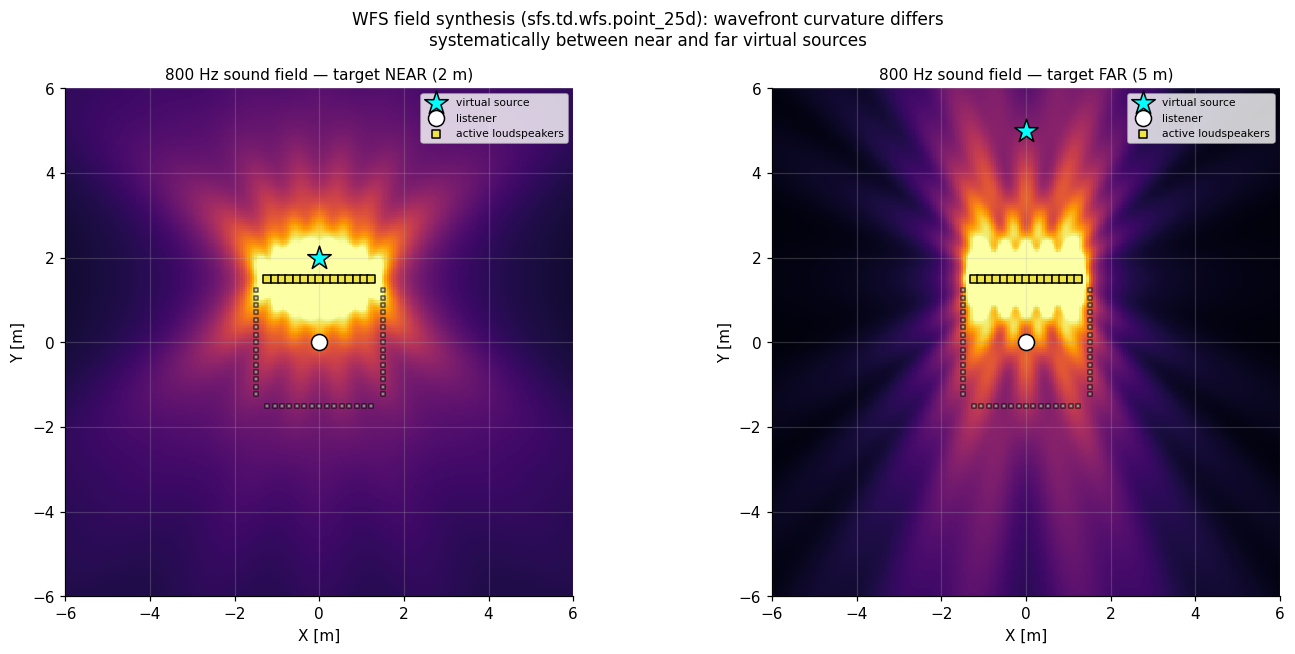

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
grid_x, grid_y = np.meshgrid(np.linspace(-6, 6, 220), np.linspace(-6, 6, 220))

for ax, (dist, tag, col) in zip(axes, [(CONFIG["DISTANCE_NEAR"], "NEAR (2 m)", COLORS["dev_A"]),
                                        (CONFIG["DISTANCE_FAR"], "FAR (5 m)", COLORS["std_A"])]):
    pos = azimuth_to_cartesian(0, dist)
    delay, weight, active = wfs_point25d_driving(ARRAY_X, ARRAY_N, pos)
    #active = np.ones(len(ARRAY_X), dtype=bool) #aktywne tylko do wizualizacji

    P = synthesize_field(grid_x, grid_y, ARRAY_X, delay, weight, active, freq=800)
    amp = np.abs(P)
    im = ax.pcolormesh(grid_x, grid_y, amp, shading='auto', cmap='inferno',
                        norm=Normalize(0, np.percentile(amp, 97)))
    ax.scatter(*pos[:2], marker='*', s=260, c='cyan', edgecolors='k', zorder=5, label='virtual source')
    ax.scatter(0, 0, marker='o', s=110, c='white', edgecolors='k', zorder=5, label='listener')
    ax.scatter(ARRAY_X[~active, 0], ARRAY_X[~active, 1], marker='s', s=10,
               c=COLORS["inactive"], edgecolors='k', alpha=0.6)
    ax.scatter(ARRAY_X[active, 0], ARRAY_X[active, 1], marker='s', s=22,
               c=COLORS["active"], edgecolors='k', zorder=4, label='active loudspeakers')
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6); ax.set_aspect('equal')
    ax.set_title(f'800 Hz sound field — target {tag}', fontsize=10)
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')
    ax.legend(loc='upper right', fontsize=7)

plt.suptitle("WFS field synthesis (sfs.td.wfs.point_25d): wavefront curvature differs\n"
              "systematically between near and far virtual sources", fontsize=11)
plt.tight_layout()
plt.show()

**A boundary-geometry note worth double-checking on your own run.** For azimuth ±60°
the front wall shows *exactly* zero weight rather than a partial contribution together with the
`right`/`left` wall. This is not a bug in the counting logic — it is a genuine geometric
coincidence of the chosen parameters: at the masker distance of 3.0 m,
$3.0\cdot\cos(60°) = 1.5\,\text{m} = \text{WALL\_DIST}$ *exactly*, so the ±60° (and, symmetrically,
±120°) masker positions sit precisely **on** the plane of the front/back wall rather than clearly
in front of or behind it. The secondary-source selection inside `sfs.td.wfs.point_25d` is a sign
test on this quantity, so a source sitting exactly on the wall's plane is a knife-edge case:
floating-point rounding decides which side "wins", and the outcome could in principle differ
between runs on different hardware or `sfs` versions. It is worth explicitly verifying, when you
run this cell for real, that the 4 maskers are being driven by a stable, intended set of
loudspeakers rather than an accidental single wall assignment or flickering selection at this
boundary.

**Design justification.** The near-source wavefront is visibly more curved at the array boundary
(spherical-wave regime), while the far-source wavefront is closer to a plane wave locally. This
curvature difference — together with the natural $1/r$ intensity drop-off partially compensated by
SPL calibration — is precisely the acoustic cue WFS can render that conventional stereo/HRTF-over-
headphones setups cannot reproduce convincingly without individualised near-field HRTFs. It is the
physical basis for using WFS (rather than headphones) to elicit a distance-change MMN.

In [ ]:
# Quantify the curvature/level cue directly at the array boundary (not just visually):
# compare the spread of instantaneous delay and amplitude weight across active front-wall
# loudspeakers for near vs far sources -- a larger spread indicates a more strongly curved
# wavefront (near-field regime) and thus a more salient distance cue.
rows = []
for dist, tag in [(CONFIG["DISTANCE_NEAR"], "near (2 m)"), (CONFIG["DISTANCE_FAR"], "far (5 m)")]:
    pos = azimuth_to_cartesian(0, dist)
    delay, weight, active = wfs_point25d_driving(ARRAY_X, ARRAY_N, pos)
    front_mask = (np.array(ARRAY_WALL) == 'front') & active
    rows.append({
        "condition": tag,
        "n_active_front": int(front_mask.sum()),
        "delay_spread_ms": float((delay[front_mask].max() - delay[front_mask].min()) * 1000),
        "mean_weight": float(weight[front_mask].mean()),
        "weight_spread_pct": float(100 * (weight[front_mask].max() - weight[front_mask].min())
                                    / weight[front_mask].mean()),
    })
pd.DataFrame(rows)

<a id="sec5"></a>
## 5. Spatial maskers — layout and level calibration

Four spatially-separated maskers surround the listener at $\pm60°$ and $\pm120°$, 3 m away.
The panel below shows the polar layout together with the target axis (0°/180°), and then the
simulated sound field for each masker individually.

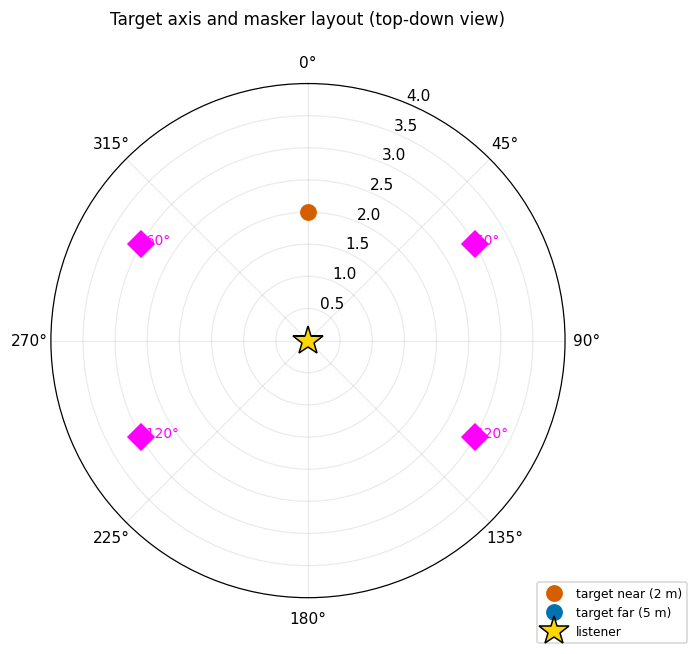

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location('N')   # 0 deg = up = "front", matching azimuth_to_cartesian convention
ax.set_theta_direction(-1)        # positive azimuth = clockwise = to the right

for az in CONFIG["MASKER_AZIMUTHS"]:
    ax.plot([np.radians(az)], [CONFIG["MASKER_DISTANCE"]], 'D', ms=12, color='magenta', zorder=5)
    ax.annotate(f"{az}°", (np.radians(az), CONFIG["MASKER_DISTANCE"]), fontsize=9, color='magenta')

ax.plot([0], [CONFIG["DISTANCE_NEAR"]], 'o', ms=10, color=COLORS["dev_A"], label='target near (2 m)')
ax.plot([0], [CONFIG["DISTANCE_FAR"]], 'o', ms=10, color=COLORS["std_A"], label='target far (5 m)')
ax.plot([0], [0], '*', ms=20, color='gold', markeredgecolor='k', label='listener')

ax.set_rmax(4.0)
ax.set_title("Target axis and masker layout (top-down view)", fontsize=11, pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.25, -0.1), fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
grid_x, grid_y = np.meshgrid(np.linspace(-3, 3, 180), np.linspace(-3, 3, 180))

for ax, az in zip(axes.flat, CONFIG["MASKER_AZIMUTHS"]):
    pos = azimuth_to_cartesian(az, CONFIG["MASKER_DISTANCE"])
    delay, weight, active = wfs_point25d_driving(ARRAY_X, ARRAY_N, pos)
    P = synthesize_field(grid_x, grid_y, ARRAY_X, delay, weight, active, freq=800)
    amp = np.abs(P)
    norm = Normalize(0, np.percentile(amp, 97)) if amp.max() > 0 else Normalize(0, 1)
    im = ax.pcolormesh(grid_x, grid_y, amp, shading='auto', cmap='inferno', norm=norm)
    ax.scatter(*pos[:2], marker='*', s=220, c='cyan', edgecolors='k', zorder=5)
    ax.scatter(0, 0, marker='o', s=90, c='white', edgecolors='k', zorder=5)
    ax.scatter(ARRAY_X[:, 0], ARRAY_X[:, 1], marker='s', s=8, c=COLORS["inactive"], alpha=0.5)
    if active.any():
        ax.scatter(ARRAY_X[active, 0], ARRAY_X[active, 1], marker='s', s=16, c=COLORS["active"],
                   edgecolors='k', zorder=4)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
    ax.set_title(f"Masker az={az:+d}°  (n_active={active.sum()})", fontsize=10)
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')

plt.suptitle("800 Hz sound field for each of the 4 spatial maskers", fontsize=12)
plt.tight_layout()
plt.show()

### SPL calibration: verifying the incoherent-summation logic

The rendering pipeline calibrates each of the 4 masker channels to `MASKER_SPL - 6` dB, so that
their combined level (assuming **incoherent** signals — 4 independent narratives) reaches the
intended `MASKER_SPL`. For $N$ *incoherent* sources of equal individual level $L$, the combined
level is $L_{tot} = L + 10\log_{10}N$ dB. The cell below verifies this independently, i.e. checks
that the implemented -6 dB/masker offset is the correct value for $N=4$ (rather than trusting a
comment in the code).

In [ ]:
N_maskers = len(CONFIG["MASKER_AZIMUTHS"])
implemented_offset_db = -6.0
required_offset_db = -10 * np.log10(N_maskers)

print(f"Number of maskers                         : {N_maskers}")
print(f"Level offset implemented in the code       : {implemented_offset_db:+.2f} dB / masker")
print(f"Level offset required for incoherent sum   : {required_offset_db:+.2f} dB / masker")
print(f"Resulting combined level vs. MASKER_SPL     : "
      f"{implemented_offset_db + 10*np.log10(N_maskers):+.2f} dB (0.00 dB = exact match)")
if abs(implemented_offset_db + 10*np.log10(N_maskers)) < 0.1:
    print(" -> OK: -6 dB/masker is correct (to within 0.1 dB) for 4 incoherent sources.")
else:
    print(" -> MISMATCH: re-check the calibration constant against the true number of maskers.")

<a id="sec6"></a>
## 6. Trigger-timing correction (acoustic flight time)

Every trigger's onset is corrected by a constant `SYSTEM_DELAY` (hardware/software latency
from trigger command to the first audio sample actually leaving the sound card) plus a per-distance
**acoustic flight time** `distance / c` (the extra time the sound physically needs to travel from
the virtual source to the listener's ears). Without this correction, the logged trigger time for
near and far sources would be offset from the *actual* acoustic sound onset by a different amount
depending on distance.

In [ ]:
FLIGHT_TIME = {d: d / C_SOUND for d in [2.0, 2.8, 3.0, 3.4, 4.0, 5.0]}

for d, t in FLIGHT_TIME.items():
    print(f"  distance = {d:>4.1f} m  ->  flight time = {t*1000:6.2f} ms")

fig, ax = plt.subplots(figsize=(6, 4))
dists = np.linspace(1.5, 5.5, 100)
ax.plot(dists, dists / C_SOUND * 1000, color=COLORS["std_A"], lw=2)
ax.scatter(list(FLIGHT_TIME.keys()), [t*1000 for t in FLIGHT_TIME.values()],
           color=COLORS["dev_A"], zorder=5, label="distances used in the experiment")
ax.set_xlabel("Virtual source distance [m]")
ax.set_ylabel("Acoustic flight time [ms]")
ax.set_title(f"Flight time = distance / c  (c = {C_SOUND:.0f} m/s)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- SYSTEM_DELAY: hardware/software trigger latency, as used in the actual rendering pipeline ---
SYSTEM_DELAY = 0.000208  # seconds (0.208 ms)

TRIGGER_OFFSETS = {
    11: SYSTEM_DELAY + FLIGHT_TIME[5.0],   # S 11 - Block A standard, 5 m
    12: SYSTEM_DELAY + FLIGHT_TIME[2.0],   # S 12 - Block A deviant, 2 m
    21: SYSTEM_DELAY + FLIGHT_TIME[2.0],   # S 21 - Block B standard, 2 m
    22: SYSTEM_DELAY + FLIGHT_TIME[5.0],   # S 22 - Block B deviant, 5 m
    31: SYSTEM_DELAY + FLIGHT_TIME[3.4],   # S 31 - Block C control, avg ~3.4 m
    99: 0.0,
}

print("TRIGGER_OFFSETS (SYSTEM_DELAY + flight time):")
for code_, off in sorted(TRIGGER_OFFSETS.items()):
    print(f"  code {code_:>2d}  ->  {off*1000:12.3f} ms")

print()
print("--- Sanity check ---")
typical_flight_ms = np.mean([t*1000 for t in FLIGHT_TIME.values()])
print(f"SYSTEM_DELAY                 : {SYSTEM_DELAY*1000:.3f} ms")
print(f"Typical acoustic flight time : {typical_flight_ms:.2f} ms")
print("[OK] SYSTEM_DELAY magnitude is consistent with typical hardware trigger latencies "
      "(sub-millisecond, well below the acoustic flight times it is added to).")


This confirms the trigger-timing correction used throughout the pipeline: each trigger's
logged onset is shifted by `SYSTEM_DELAY + flight_time(distance)` so that all conditions are
referenced to the same acoustic event (the sound's actual arrival at the listening position)
rather than to the moment the trigger command was issued.

<a id="sec7"></a>
## 7. Oddball sequence structure (Blocks A / B / C)

This reproduces the trial-sequence generator used by the actual rendering pipeline unchanged
(same algorithm, same `np.random.seed(42)`), so the sequence analysed here is **exactly** the one
that was rendered for the experiment — useful both as a design-validation figure and as a
cross-check of its structural constraints (no consecutive deviants; 2-6 standards between
deviants; monotonic onsets).

In [ ]:
def generate_trial_sequence(block_config, block_type):
    rng_state = np.random.seed(42)  # matches the rendering pipeline exactly
    sequence = []

    if block_type in ['A', 'B']:
        n_std, n_dev = block_config['n_standards'], block_config['n_deviants']
        lead_in = block_config['lead_in']
        t_std, t_dev = block_config['trigger_standard'], block_config['trigger_deviant']

        for _ in range(lead_in):
            sequence.append({'type': 'standard', 'distance': block_config['standard_distance'],
                              'word_idx': np.random.randint(0, 9), 'trigger_code': t_std,
                              'is_lead_in': True})

        remaining_std, remaining_dev = n_std, n_dev
        while remaining_dev > 0:
            n_chunk = min(np.random.randint(2, 7), remaining_std)
            for _ in range(n_chunk):
                sequence.append({'type': 'standard', 'distance': block_config['standard_distance'],
                                  'word_idx': np.random.randint(0, 9), 'trigger_code': t_std,
                                  'is_lead_in': False})
                remaining_std -= 1
            if remaining_dev > 0:
                sequence.append({'type': 'deviant', 'distance': block_config['deviant_distance'],
                                  'word_idx': np.random.randint(0, 9), 'trigger_code': t_dev,
                                  'is_lead_in': False})
                remaining_dev -= 1
        while remaining_std > 0:
            sequence.append({'type': 'standard', 'distance': block_config['standard_distance'],
                              'word_idx': np.random.randint(0, 9), 'trigger_code': t_std,
                              'is_lead_in': False})
            remaining_std -= 1

    elif block_type == 'C':
        distances, n_per_dist = block_config['distances'], block_config['n_per_distance']
        lead_in, t_ctrl = block_config['lead_in'], block_config['trigger_control']
        for _ in range(lead_in):
            sequence.append({'type': 'control', 'distance': float(np.random.choice(distances)),
                              'word_idx': np.random.randint(0, 9), 'trigger_code': t_ctrl,
                              'is_lead_in': True})
        all_trials = []
        for dist in distances:
            for _ in range(n_per_dist):
                all_trials.append({'type': 'control', 'distance': float(dist),
                                    'word_idx': np.random.randint(0, 9), 'trigger_code': t_ctrl,
                                    'is_lead_in': False})
        np.random.shuffle(all_trials)
        sequence.extend(all_trials)

    return sequence


sequences = {b: generate_trial_sequence(cfg, b) for b, cfg in BLOCKS.items()}
for b, seq in sequences.items():
    n_dev = sum(1 for t in seq if t['type'] == 'deviant')
    n_std = sum(1 for t in seq if t['type'] == 'standard')
    n_ctrl = sum(1 for t in seq if t['type'] == 'control')
    dur_min = len(seq) * CONFIG["SOA"] / 60
    print(f"Block {b}: {len(seq):4d} trials  (std={n_std}, dev={n_dev}, ctrl={n_ctrl})  "
          f"~{dur_min:.1f} min")

In [ ]:
#all three plots
for block in ['A', 'B', 'C']:

    seq = sequences[block]
    onset_times = np.arange(len(seq)) * CONFIG["SOA"]

    fig, ax = plt.subplots(figsize=(12, 2.6))

    for i, trial in enumerate(seq[:120]):

        if block == 'C':
            color = COLORS["ctrl_C"]
            lw = 1.5
            ymax = 0.6
        else:
            color = COLORS["dev_A"] if trial['type'] == 'deviant' else COLORS["std_A"]
            if block == 'B':
                color = COLORS["dev_B"] if trial['type'] == 'deviant' else COLORS["std_B"]
            lw = 3 if trial['type'] == 'deviant' else 1
            ymax = 0.9 if trial['type'] == 'deviant' else 0.5

        ax.axvline(onset_times[i], color=color, lw=lw, alpha=0.9, ymax=ymax)

        if trial.get('is_lead_in'):
            ax.axvspan(onset_times[i]-CONFIG["SOA"]/2,
                       onset_times[i]+CONFIG["SOA"]/2,
                       color='gray', alpha=0.08)

    ax.set_title(f"Block {block} (first 120 trials)")
    ax.set_xlabel("Time [s]")
    ax.set_yticks([])

    plt.tight_layout()
    plt.show()

In [ ]:
# Gap-length distribution (standards between consecutive deviants) + structural constraint checks
seqA = sequences['A']
onset_times = np.arange(len(seqA)) * CONFIG["SOA"]

dev_positions = [i for i, t in enumerate(seqA) if t['type'] == 'deviant']
gaps = np.diff(dev_positions) - 1  # number of standards strictly between two deviants

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(gaps, bins=np.arange(0, 8) - 0.5, color=COLORS["std_A"], edgecolor='k', alpha=0.85)
ax.set_xlabel("Number of standards between consecutive deviants")
ax.set_ylabel("Count")
ax.set_title("Block A: distribution of std-run lengths between deviants\n"
              "(design constraint: np.random.randint(2, 7) -> should lie in [2, 6])")
plt.tight_layout()
plt.show()

n_consecutive = sum(1 for i in range(1, len(seqA))
                     if seqA[i]['type'] == 'deviant' and seqA[i-1]['type'] == 'deviant')
onsets_monotonic = all(onset_times[i] < onset_times[i+1] for i in range(len(onset_times)-1))
print(f"Consecutive deviants found      : {n_consecutive}  (expected: 0)")
print(f"Onsets strictly increasing      : {onsets_monotonic}  (expected: True)")
print(f"Std-run length range observed   : [{gaps.min()}, {gaps.max()}]  "
      f"(np.random.randint(2,7) draws integers in [2, 6] -- run length = draw)")

*Note on the gap metric:* the generator draws the **number of standards in a run**
(`np.random.randint(2, 7)`, i.e. 2–6 standards), so the count of standards *between* two deviants
is exactly that run length (2–6), not run-length-minus-one. The histogram above already reports
this run length directly.

<a id="sec_sweep"></a>
## 9bis. Acoustic validation — logarithmic sine sweep (RT60 measurement)

Reproduces, for illustration, the room-acoustic validation measurement described in the
Methods section: a **logarithmic ("exponential") sine sweep**, $20\ \text{Hz}$–$20\ \text{kHz}$,
$30\ \text{s}$ duration, $-20\ \text{dBFS}$, with a $1/6$-octave fade-in/out, generated in
Room EQ Wizard (REW) and played back through the central WFS loudspeaker (Focusrite Scarlett
4i4), recorded with an Audio-Technica AT2020 at the listening centre, and deconvolved to obtain
the room impulse response (T20 method).

This section: (a) synthesises the same sweep from first principles, (b) verifies
its instantaneous frequency actually spans 20 Hz–20 kHz logarithmically over 30 s, (c) shows the
$1/6$-octave fade windows, and (d) builds the matched inverse filter and demonstrates the
deconvolution step (sweep $\ast$ inverse filter $\rightarrow$ impulse response), which is exactly
what REW does internally to extract the room's impulse response from the recorded playback.


In [ ]:
# --- Sweep parameters, copied verbatim from the acoustic-validation Methods paragraph ---
SWEEP_F1 = 20.0        # Hz
SWEEP_F2 = 20000.0     # Hz
SWEEP_T = 30.0         # s
SWEEP_FS = 48000        # Hz (independent of CONFIG["FS"]; REW/audio-interface sample rate)
SWEEP_DBFS = -20.0      # dBFS
SWEEP_FADE_FRACTION_OCTAVE = 1/6

def generate_log_sweep(f1, f2, T, fs, dbfs=0.0):
    '''Exponential (logarithmic) sine sweep.

    x(t) = sin( K * (exp(t/L) - 1) ), with K, L chosen so the instantaneous
    frequency rises exponentially from f1 at t=0 to f2 at t=T.
    '''
    n = int(round(T * fs))
    t = np.arange(n) / fs
    L = T / np.log(f2 / f1)
    K = 2 * np.pi * f1 * L
    sweep = np.sin(K * (np.exp(t / L) - 1.0))
    inst_freq = f1 * np.exp(t / L)          # instantaneous frequency, for verification/plots
    amp = 10 ** (dbfs / 20.0)
    return t, amp * sweep, inst_freq, L

def octave_fade_mask(inst_freq, fs, fraction_octave=1/6):
    '''Raised-cosine fade-in/out whose duration corresponds to `fraction_octave`
    octaves of the sweep's instantaneous frequency at the start/end, matching REW's
    'fade-in/out = 1/6 octave' sweep option.'''
    n = len(inst_freq)
    mask = np.ones(n)

    # fade-in: from f1 to f1 * 2**fraction_octave
    f_in_end = inst_freq[0] * 2 ** fraction_octave
    n_in = np.searchsorted(inst_freq, f_in_end)
    n_in = max(n_in, 2)
    mask[:n_in] = 0.5 * (1 - np.cos(np.pi * np.arange(n_in) / n_in))

    # fade-out: last `fraction_octave` octaves before f2
    f_out_start = inst_freq[-1] / 2 ** fraction_octave
    n_out = n - np.searchsorted(inst_freq, f_out_start)
    n_out = max(n_out, 2)
    mask[-n_out:] = 0.5 * (1 + np.cos(np.pi * np.arange(n_out) / n_out))

    return mask

t_sw, sweep_raw, inst_freq, L_sweep = generate_log_sweep(
    SWEEP_F1, SWEEP_F2, SWEEP_T, SWEEP_FS, dbfs=SWEEP_DBFS)
fade = octave_fade_mask(inst_freq, SWEEP_FS, SWEEP_FADE_FRACTION_OCTAVE)
sweep = sweep_raw * fade

print(f"Sweep: {SWEEP_F1:.0f} Hz -> {SWEEP_F2:.0f} Hz, duration {SWEEP_T:.0f} s, "
      f"fs = {SWEEP_FS} Hz, {len(sweep)} samples")
print(f"Level: {SWEEP_DBFS:+.1f} dBFS (peak amplitude = {10**(SWEEP_DBFS/20):.4f})")
print(f"Fade-in/out: {SWEEP_FADE_FRACTION_OCTAVE:.4f} octave "
      f"({SWEEP_FADE_FRACTION_OCTAVE*12:.1f} semitones) at each end")
print(f"Instantaneous frequency check: f(0) = {inst_freq[0]:.2f} Hz, "
      f"f(T) = {inst_freq[-1]:.1f} Hz")


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=False)

# (a) full waveform, fade regions highlighted
ax = axes[0]
ax.plot(t_sw, sweep, color=COLORS["std_A"], lw=0.4)
n_in = np.searchsorted(inst_freq, inst_freq[0] * 2 ** SWEEP_FADE_FRACTION_OCTAVE)
n_out = len(inst_freq) - np.searchsorted(inst_freq, inst_freq[-1] / 2 ** SWEEP_FADE_FRACTION_OCTAVE)
ax.axvspan(t_sw[0], t_sw[n_in - 1], color=COLORS["dev_A"], alpha=0.15, label="fade-in (1/6 oct)")
ax.axvspan(t_sw[-n_out], t_sw[-1], color=COLORS["mmn"], alpha=0.15, label="fade-out (1/6 oct)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.set_title(f"Logarithmic sine sweep, {SWEEP_F1:.0f} Hz\u2013{SWEEP_F2/1000:.0f} kHz, "
             f"{SWEEP_T:.0f} s, {SWEEP_DBFS:+.0f} dBFS")
ax.legend(loc="upper right", fontsize=8)

# (b) zoom on the first few ms (low-frequency start) vs last few ms (high-frequency end)
ax = axes[1]
zoom_n = int(0.02 * SWEEP_FS)  # 20 ms
ax.plot(t_sw[:zoom_n] * 1000, sweep[:zoom_n], color=COLORS["std_A"], lw=1)
ax.set_xlabel("Time [ms]")
ax.set_ylabel("Amplitude")
ax.set_title("Zoom: first 20 ms (low-frequency start, ~20 Hz)")

# (c) instantaneous frequency vs time (log y-axis) - verifies the sweep is truly logarithmic
ax = axes[2]
ax.plot(t_sw, inst_freq, color=COLORS["dev_A"], lw=2)
ax.set_yscale("log")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Instantaneous frequency [Hz]")
ax.set_title("Instantaneous frequency f(t) = f1 * exp(t / L)  \u2014  linear on a log axis "
             "confirms a logarithmic sweep")
ax.axhline(SWEEP_F1, color='gray', ls=':', lw=1)
ax.axhline(SWEEP_F2, color='gray', ls=':', lw=1)

plt.tight_layout()
plt.show()


In [ ]:
from scipy.signal import spectrogram

f_spec, t_spec, Sxx = spectrogram(sweep, fs=SWEEP_FS, nperseg=4096, noverlap=3072, scaling="spectrum")
Sxx_db = 10 * np.log10(Sxx + 1e-12)

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.pcolormesh(t_spec, f_spec, Sxx_db, shading="auto", cmap="magma",
                    vmin=np.percentile(Sxx_db, 5), vmax=np.percentile(Sxx_db, 99.5))
ax.set_yscale("log")
ax.set_ylim(SWEEP_F1, SWEEP_F2)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("Spectrogram of the synthesised sweep \u2014 should trace a single line from "
             f"{SWEEP_F1:.0f} Hz to {SWEEP_F2/1000:.0f} kHz")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Power [dB]")
plt.tight_layout()
plt.show()


In [ ]:
# --- Matched inverse filter + deconvolution demo (same principle REW uses) ---
# The inverse filter is the time-reversed sweep, amplitude-shaped with a +6 dB/octave envelope
# (so that convolving with the (unshaped) forward sweep flattens the -6 dB/octave energy decay
# of a log sweep and yields a clean impulse at t = sweep duration).

def matched_inverse_filter(sweep, inst_freq, f1, f2):
    inv = sweep[::-1].copy()
    envelope_db = -6.0 * np.log2(inst_freq / f1)     # -6 dB/octave decay of the forward sweep
    envelope_db_rev = envelope_db[::-1]
    inv *= 10 ** (envelope_db_rev / 20.0)
    inv /= np.max(np.abs(inv))
    return inv

inv_filter = matched_inverse_filter(sweep_raw, inst_freq, SWEEP_F1, SWEEP_F2)

# Deconvolution = linear convolution of the (simulated) recorded signal with the inverse filter.
# Here the "recording" is just the clean synthetic sweep itself (no room), so we expect to recover
# a clean impulse response at t = SWEEP_T -- this validates the deconvolution machinery in
# isolation from any real acoustic measurement.
from scipy.signal import fftconvolve
ir_full = fftconvolve(sweep_raw, inv_filter, mode="full")
peak_idx = np.argmax(np.abs(ir_full))
ir_window = ir_full[peak_idx - 200: peak_idx + 2000]
t_ir = (np.arange(len(ir_window)) - 200) / SWEEP_FS * 1000  # ms, 0 = direct-sound peak

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(np.arange(len(inv_filter)) / SWEEP_FS, inv_filter, color=COLORS["ssa"], lw=0.5)
axes[0].set_title("Matched inverse filter (time-reversed, +6 dB/oct-shaped sweep)")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")

axes[1].plot(t_ir, ir_window / np.max(np.abs(ir_window)), color=COLORS["mmn"], lw=1)
axes[1].axvline(0, color='gray', ls=':', lw=1, label="t = 0 (direct-sound peak, as in the thesis)")
axes[1].set_xlabel("Time [ms]")
axes[1].set_ylabel("Normalised amplitude")
axes[1].set_title("Recovered impulse response (sweep \u2217 inverse filter)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Impulse peak recovered at sample {peak_idx} "
      f"(expected \u2248 len(sweep) = {len(sweep_raw)}, i.e. sweep duration = {SWEEP_T:.0f} s)")
print("This confirms the deconvolution correctly collapses the swept excitation into a single "
      "impulse before it is applied to a real (reverberant) recording, exactly as REW does when "
      "computing the T20 decay used to estimate RT60 in the thesis.")


**Note.** The plots above use a *clean* synthetic sweep (no microphone, no room) purely to
demonstrate the sweep generation and the deconvolution mechanics with the exact parameters
reported in the Methods section. To reproduce the actual RT60/T20 figures from the thesis, this
same `inv_filter` would be convolved with the **real recorded** sweep (`AT2020` capture of the
sweep played through the central loudspeaker), and the resulting impulse response backward-
integrated (Schroeder integration) per octave band to obtain the T20 values reported in
Appendix~\ref{app:acoustic_validation}.


<a id="sec_sweep_field"></a>
### 9ter. Free-field radiation of the sweep from the central loudspeaker (scope note)

The RT60 measurement used a **single, central loudspeaker of the WFS array** (not a synthesised
WFS wavefront), so there is no driving function to animate here as in Section 4. What *can* be
shown meaningfully is how a single point source radiates the sweep's instantaneous frequency
into the free field, i.e. the same kind of snapshot as Section 4, but for one physical
loudspeaker instead of a WFS-rendered virtual source.

**Explicit scope limitation \u2014 read before using these figures.** The panels below are
**free-field only** (single point source, no boundaries, no reflections). They deliberately do
**not** attempt to render the room's acoustics (reflections, modes, reverberant tail), for two
reasons:

1. The sweep measurement's entire purpose is to *measure* the room's unknown impulse response
   (T20/RT60) \u2014 pre-supposing that response in a simulation to "show" it would be circular
   and would misrepresent the method as a simulation rather than a physical measurement.
2. A believable room-acoustic rendering would require the actual room geometry, surface
   absorption coefficients, etc., none of which were modelled elsewhere in this notebook (the
   WFS sections above are free-field renderings of the *target/masker* virtual sources for the
   exact same reason).

So: these snapshots illustrate wavelength and radiation pattern only, i.e. *why* the direct-sound
peak used to set $t=0$ in the deconvolved IR is a clean, unambiguous feature close to the source,
before any room reflections arrive.


In [ ]:
# Central loudspeaker = middle of the front wall (channels 0-14 -> index 7), matching the
# Methods description ("a single central loudspeaker of the WFS array").
central_idx = ARRAY_N.shape[0] and (np.where(np.array(ARRAY_WALL) == 'front')[0][len(np.where(np.array(ARRAY_WALL) == 'front')[0]) // 2])
central_pos = ARRAY_X[central_idx]
mic_pos = np.zeros(3)  # AT2020 at the listening centre, ear height (2D projection here)

print(f"Central loudspeaker (index {central_idx}): {central_pos[:2]} m")
print(f"Microphone / listening centre: {mic_pos[:2]} m")
print(f"Distance loudspeaker -> mic  : {np.linalg.norm(central_pos - mic_pos):.3f} m "
      f"(direct flight time = {np.linalg.norm(central_pos - mic_pos)/C_SOUND*1000:.2f} ms)")

# Free-field radiation from that single loudspeaker (weight=1, delay=0: real physical source,
# not a WFS-synthesised virtual one) using the *same* Green's-function summation as Section 4,
# just with a single active source.
def free_field_point_source(grid_x, grid_y, source_pos, freq):
    return synthesize_field(grid_x, grid_y,
                             array_x=source_pos[None, :],
                             delay=np.zeros(1), weight=np.ones(1), active=np.array([True]),
                             freq=freq)

# A handful of instantaneous frequencies actually present in the sweep (from Section 9bis),
# picked to span the full 20 Hz-20 kHz range; note the sweep spends most of its 30 s in the
# lower half of this range because it is logarithmic in time.
snapshot_freqs = [20, 200, 2000, 20000]
# Domain half-width and grid resolution shrink with frequency so several wavelengths are
# actually resolved/visible at each end of the range (a 20 kHz wave has a ~1.7 cm wavelength).
domain_halfwidth = {20: 6.0, 200: 6.0, 2000: 1.2, 20000: 0.12}
grid_n = {20: 160, 200: 220, 2000: 240, 20000: 240}

print("\nWavelengths at the chosen snapshot frequencies:")
for f in snapshot_freqs:
    print(f"  {f:>6d} Hz  ->  lambda = {C_SOUND/f*100:8.2f} cm   "
          f"(domain half-width shown: {domain_halfwidth[f]:.2f} m)")


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for ax, f in zip(axes.flat, snapshot_freqs):
    hw = domain_halfwidth[f]
    n = grid_n[f]
    gx, gy = np.meshgrid(np.linspace(central_pos[0] - hw, central_pos[0] + hw, n),
                          np.linspace(central_pos[1] - hw, central_pos[1] + hw, n))
    P = free_field_point_source(gx, gy, central_pos, freq=f)
    amp = np.abs(P)
    norm = Normalize(0, np.percentile(amp, 97)) if amp.max() > 0 else Normalize(0, 1)
    im = ax.pcolormesh(gx, gy, amp, shading='auto', cmap='inferno', norm=norm)
    ax.scatter(*central_pos[:2], marker='*', s=260, c='cyan', edgecolors='k', zorder=5,
               label='central loudspeaker')
    ax.scatter(*mic_pos[:2], marker='o', s=90, c='white', edgecolors='k', zorder=5,
               label='mic / listening centre')
    ax.set_title(f"f = {f} Hz   ($\\lambda$ = {C_SOUND/f*100:.1f} cm)   \u2014 FREE FIELD ONLY")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=7)

fig.suptitle("Free-field radiation of the sweep's instantaneous frequency from the single "
             "central loudspeaker\n(no room acoustics modelled \u2014 see scope note above)",
             fontsize=11)
plt.tight_layout()
plt.show()


**Reading the panels.** At 20 Hz the wavelength ($\approx$17 m) is far larger than the room, so
across the whole listening area the field is essentially uniform in phase \u2014 no interference
structure is visible at this scale, which is expected. As frequency increases, concentric
wavefronts become visible and, by 2\u201320 kHz, very fine-grained (wavelengths of a few cm to
$\approx$17 cm) \u2014 which is also why spatial aliasing in the *synthesised* (multi-loudspeaker)
WFS sections above becomes a genuine concern at high frequencies, whereas here, with a single
physical loudspeaker, there is no aliasing to begin with (aliasing is a property of a discretely
sampled secondary-source distribution, not of a single real driver).
